### 자연어 task 중 하나인 MNLI를 해결하는 모델을 HuggingFace로 학습

* MNLI를 요약하면 다음과 같습니다.

  - **입력**: premise에 해당하는 문장과 hypothesis에 해당하는 문장 두 개가 입력으로 들어옵니다.
  - **출력:** 분류 문제로, 두 문장이 들어왔을 때 다음 세 가지를 예측하시면 됩니다.
    - **Entailment:** 두 문장에 논리적 모순이 없습니다.
    - **Neutral:** 두 문장은 논리적으로 관련이 없습니다.
    - **Contradiction:** 두 문장 사이에 논리적 모순이 존재합니다.

---
#### 작업목표
- [ ]  load_dataset("nyu-mll/glue", "mnli") 로 dataset을 불러옵니다.
    - 학습 때는 train split만 활용, 나머지 split은 사용불가
    - Validation data가 필요한 경우, train split에서 가져와야함
- [ ]  trainer.train()를 통해 학습된 log가 남아있어야 함
- [ ]  Dataset의 validation_matched에 대한 성능을 출력하고, 50% 이상

---

In [ ]:

!pip install transformers datasets evaluate


## 2. 데이터셋 로드
---

In [2]:
from datasets import load_dataset

mnli = load_dataset("nyu-mll/glue", "mnli")
train_data = mnli['train']
# validation_matched는 나중 평가용으로만 사용


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

(…)alidation_matched-00000-of-00001.parquet:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

(…)dation_mismatched-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

In [3]:
train_data

Dataset({
    features: ['premise', 'hypothesis', 'label', 'idx'],
    num_rows: 392702
})

In [4]:
import pandas as pd


pd.DataFrame(train_data[:5])

,premise,hypothesis,label,idx
0,Conceptually cream skimming has two basic dime...,Product and geography are what make cream skim...,1,0
1,you know during the season and i guess at at y...,You lose the things to the following level if ...,0,1
2,One of our number will carry out your instruct...,A member of my team will execute your orders w...,0,2
3,How do you know? All this is their information...,This information belongs to them.,0,3
4,yeah i tell you what though if you go price so...,The tennis shoes have a range of prices.,1,4


## 3. Validation 분할
---

In [5]:
# train에서 일부를 validation으로 분할
train_data = train_data.train_test_split(test_size=0.1)
train_ds = train_data['train']
val_ds = train_data['test']


In [6]:
train_ds

Dataset({
    features: ['premise', 'hypothesis', 'label', 'idx'],
    num_rows: 353431
})

In [7]:
train_ds[0]

{'premise': 'Perfectly. ',
 'hypothesis': 'Without any errors.',
 'label': 1,
 'idx': 284220}

## 4. Tokenizer 및 모델 준비
---

In [8]:
from transformers import BertTokenizerFast, BertForSequenceClassification

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 5. 전처리 및 데이터셋 포맷팅
---

In [23]:
# 학습 데이터: train의 앞 10%만 사용
# train_ds = load_dataset("nyu-mll/glue", "mnli", split="train[:10%]")
train_ds = load_dataset("nyu-mll/glue", "mnli", split="train[:5%]")

# 평가 데이터: validation_matched의 앞 10%만 사용
val_ds = load_dataset("nyu-mll/glue", "mnli", split="validation_matched[:10%]")


def preprocess(example):
    return tokenizer(example['premise'], example['hypothesis'], truncation=True, padding='max_length', max_length=128)

train_ds = train_ds.map(preprocess, batched=True)
val_ds = val_ds.map(preprocess, batched=True)
eval_ds = mnli['validation_matched'].map(preprocess, batched=True)

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
eval_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/19635 [00:00<?, ? examples/s]

## 6. Trainer 설정 및 학습
---

In [24]:
import torch


print(torch.cuda.is_available())  # True여야 함


True


6-1. Sub Mission : Wandb 사용해보기
---

<details>
<summary>🔍 왜 wandb를 써야 할까? (입문자용 설명 포함)</summary>

### 🧑‍🔬 왜 wandb를 써야 할까?

모델을 하나만 학습시켜보고 끝내는 실험은 거의 없습니다.  
wandb는 **모델 실험 과정을 자동으로 기록하고 시각화해주는 도구**입니다.  
처음에는 단순한 그래프 시각화부터 시작해서, 나중엔 수십 개 실험을 비교하고 분석하는 데 큰 도움이 됩니다.

---

### 🛠️ 기초 기능 (입문자 필수)

- **1. 실시간 Loss / Accuracy 그래프**  
  `print()`로 로그 찍는 대신, wandb는 학습이 진행되면서 자동으로 loss/accuracy를 그래프로 그려줍니다.  
  → 어떤 에폭에서 학습이 잘 되는지 직관적으로 확인 가능.

- **2. 하이퍼파라미터 기록**  
  learning rate, batch size, 모델 구조 등을 자동으로 기록.  
  → 나중에 어떤 설정으로 실험했는지 기억 못해도 걱정 없음.

- **3. 실험 자동 백업**  
  코드, 로그, 결과를 모두 저장해서 **실험 재현 가능성**을 높여줌.  
  → 논문 쓸 때 “재현 가능한 실험 환경” 제공에 도움.

---

### 🚀 중급 기능 (조금 익숙해지면 유용)

- **4. 여러 실험 비교**  
  실험을 여러 개 해도, wandb는 한 화면에서 loss/accuracy를 겹쳐서 보여줌.  
  → 어떤 설정이 더 좋았는지 바로 비교 가능.

- **5. 모델 아키텍처 / 파라미터 수 시각화**  
  모델 구조를 한눈에 확인 가능. 복잡한 모델을 디버깅할 때 매우 유용.

- **6. 체크포인트 자동 저장**  
  특정 에폭마다 모델 가중치를 저장하게 설정할 수 있음.  
  → 중간에 멈춰도 이어서 학습 가능, 모델 선택도 편리.

---

### 🧠 고급 기능 (프로젝트가 커질수록 유용)

- **7. 하이퍼파라미터 스윕 (자동 실험 조합 실행)**  
  learning rate, hidden size 등 조합을 지정하면 wandb가 자동으로 여러 실험을 돌려줌.  
  → 일일이 실험 안 돌려도 되고, 최적 설정 찾기 쉬움.

- **8. 팀 협업 & 공유**  
  실험 결과를 웹 대시보드로 공유 가능. 교수님, 팀원에게 결과 보여주기 좋음.

- **9. Colab / Jupyter 완벽 호환**  
  설치만 하면 바로 사용 가능.  
  → `wandb.init()` 한 줄로 시작 가능.

---

### 📦 Summary

wandb는 단순 로그 도구가 아니라  
→ **연구자용 실험 기록 시스템**입니다.  
모델이 커지고 실험이 많아질수록, wandb는 반드시 쓰게 될 도구예요.  
처음엔 간단하게 시작하고, 점점 더 다양한 기능을 써보면 됩니다.

</details>




In [25]:
import os
# os.environ["WANDB_DISABLED"] = "true" # 사용안함
os.environ["WANDB_DISABLED"] = "false"


In [28]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')

    # confusion matrix 저장
    global latest_confusion_matrix
    latest_confusion_matrix = confusion_matrix(labels, preds)

    # AUC 계산 준비 (label을 one-hot encoding)
    global latest_roc_data
    num_classes = logits.shape[1]
    probs = softmax(logits, axis=1)  # 다중 클래스 확률

    binarized_labels = label_binarize(labels, classes=np.arange(num_classes))  # (N, 3)
    latest_roc_data = (binarized_labels, probs)  # 전역에 저장

    # ROC-AUC (macro, micro)
    try:
        roc_auc_macro = roc_auc_score(binarized_labels, probs, average='macro', multi_class='ovr')
        roc_auc_micro = roc_auc_score(binarized_labels, probs, average='micro', multi_class='ovr')
    except:
        roc_auc_macro = 0.0
        roc_auc_micro = 0.0

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc_macro': roc_auc_macro,
        'roc_auc_micro': roc_auc_micro,
    }

def softmax(x, axis=1):
    exp_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


In [29]:
from transformers import Trainer, TrainingArguments



training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    logging_dir="./logs",
    logging_steps=100,
    save_steps=500,
    learning_rate=2e-5,
    weight_decay=0.01
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()


Step,Training Loss
100,0.074700
200,0.080600
300,0.041900
400,0.070800
500,0.069300
600,0.096000
700,0.062900
800,0.239300
900,0.247800
1000,0.214300


TrainOutput(global_step=3684, training_loss=0.09432720820885657, metrics={'train_runtime': 654.4226, 'train_samples_per_second': 90.011, 'train_steps_per_second': 5.629, 'total_flos': 3874673967816960.0, 'train_loss': 0.09432720820885657, 'epoch': 3.0})

## 7. 평가
---

In [31]:
import evaluate

metric = evaluate.load("accuracy")
preds = trainer.predict(eval_ds)
accuracy = metric.compute(predictions=preds.predictions.argmax(axis=-1), references=preds.label_ids)

print("Validation Matched Accuracy:", accuracy['accuracy'])


Validation Matched Accuracy: 0.7874681609780948


### Confusion Matrix
---

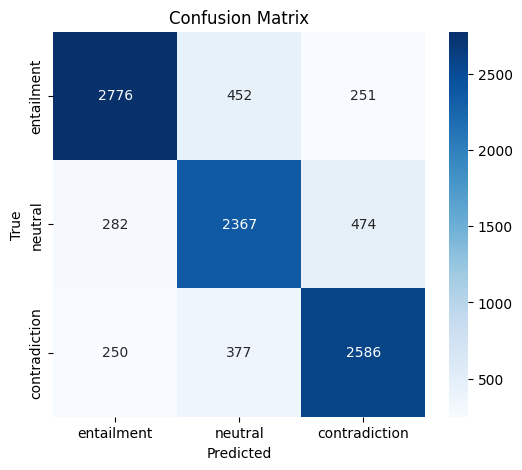

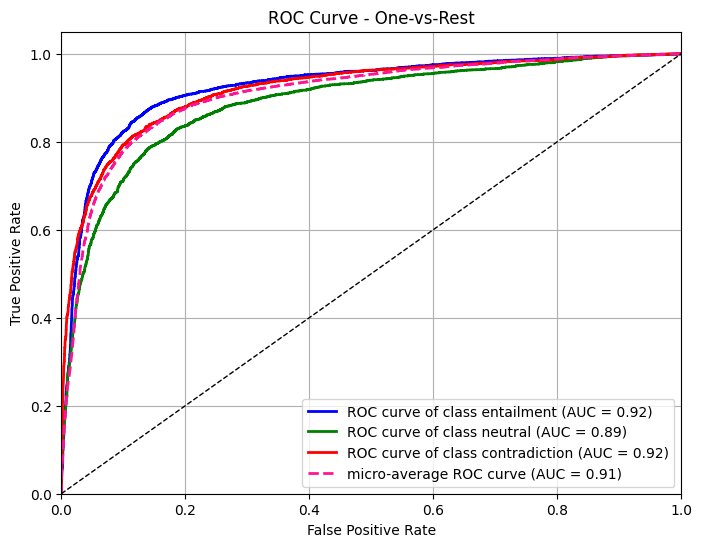

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

labels = ['entailment', 'neutral', 'contradiction']  # MNLI 클래스명

def plot_confusion(cm, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()



def plot_roc_auc(roc_data, class_names):
    y_true, y_score = roc_data
    n_classes = len(class_names)

    # 각 클래스별 ROC 곡선 계산
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # macro/micro AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--',
             label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})", lw=2)

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - One-vs-Rest")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



# Confusion Matrix
plot_confusion(latest_confusion_matrix, labels)

# ROC Curve
plot_roc_auc(latest_roc_data, labels)



---
| 항목 | 포함 |
|------|------|
| Accuracy / Precision / Recall / F1 | ✅  
| Confusion Matrix 시각화 | ✅  
| ROC-AUC (macro/micro/class) | ✅  
| AUC Curve (One-vs-Rest 방식) | ✅  

---

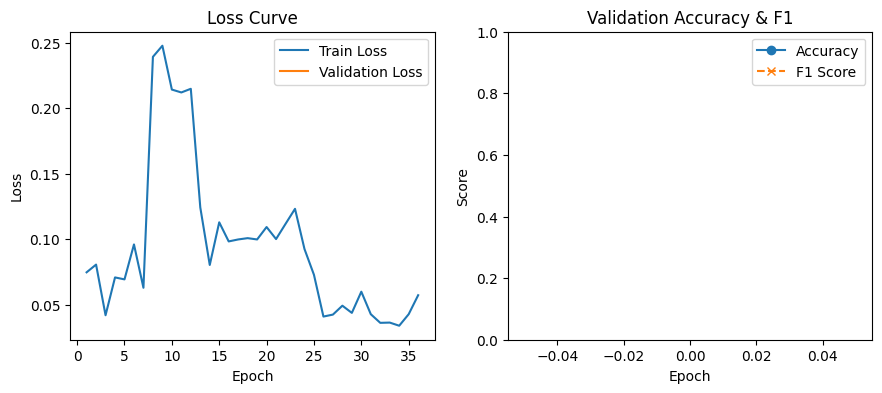

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 로그 히스토리 추출
logs = trainer.state.log_history

# Loss, Accuracy 등 추출
train_loss = [log['loss'] for log in logs if 'loss' in log]
eval_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]
eval_acc = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]
eval_precision = [log['eval_precision'] for log in logs if 'eval_precision' in log]
eval_recall = [log['eval_recall'] for log in logs if 'eval_recall' in log]
eval_f1 = [log['eval_f1'] for log in logs if 'eval_f1' in log]

# X축용: epoch 인덱스 만들기
train_epochs = list(range(1, len(train_loss)+1))
eval_epochs = list(range(1, len(eval_acc)+1))  # accuracy 기준

# Plot 구성
plt.figure(figsize=(16, 4))

# 1. Loss 그래프
plt.subplot(1, 3, 1)
plt.plot(train_epochs, train_loss, label='Train Loss')
plt.plot(eval_epochs, eval_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# 2. Accuracy & F1 그래프
plt.subplot(1, 3, 2)
plt.plot(eval_epochs, eval_acc, label='Accuracy', marker='o')
plt.plot(eval_epochs, eval_f1, label='F1 Score', linestyle='--', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy & F1")
plt.ylim(0, 1)
plt.legend()

# # 3. Precision & Recall 그래프
# plt.subplot(1, 3, 3)
# plt.plot(eval_epochs, eval_precision, label='Precision', marker='o')
# plt.plot(eval_epochs, eval_recall, label='Recall', linestyle='--', marker='x')
# plt.xlabel("Epoch")
# plt.ylabel("Score")
# plt.title("Precision / Recall")
# plt.ylim(0, 1)
# plt.legend()

# plt.tight_layout()
# plt.show()


In [34]:
for log in logs:
    print(log)


{'loss': 0.0747, 'grad_norm': 7.513278007507324, 'learning_rate': 1.946254071661238e-05, 'epoch': 0.08143322475570032, 'step': 100}
{'loss': 0.0806, 'grad_norm': 37.1186637878418, 'learning_rate': 1.8919652551574377e-05, 'epoch': 0.16286644951140064, 'step': 200}
{'loss': 0.0419, 'grad_norm': 0.0062231505289673805, 'learning_rate': 1.8376764386536375e-05, 'epoch': 0.24429967426710097, 'step': 300}
{'loss': 0.0708, 'grad_norm': 0.42509838938713074, 'learning_rate': 1.7833876221498374e-05, 'epoch': 0.3257328990228013, 'step': 400}
{'loss': 0.0693, 'grad_norm': 0.08166626840829849, 'learning_rate': 1.7290988056460372e-05, 'epoch': 0.40716612377850164, 'step': 500}
{'loss': 0.096, 'grad_norm': 41.02476501464844, 'learning_rate': 1.674809989142237e-05, 'epoch': 0.48859934853420195, 'step': 600}
{'loss': 0.0629, 'grad_norm': 36.47968292236328, 'learning_rate': 1.6205211726384368e-05, 'epoch': 0.5700325732899023, 'step': 700}
{'loss': 0.2393, 'grad_norm': 8.905648231506348, 'learning_rate': 1